In [1]:
import subprocess, sys
print("=" * 60)
print("       CÀI ĐẶT THƯ VIỆN")
print("=" * 60)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch-geometric", "rdkit"])
try:
    import torch
    import torch_geometric
    print(f"✅ PyTorch          : {torch.__version__}")
    print(f"✅ torch-geometric  : {torch_geometric.__version__}")
    print(f"   CUDA available   : {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   GPU              : {torch.cuda.get_device_name(0)}")
except ImportError as e:
    print(f"❌ Import error: {e}")
print("=" * 60)


import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"✅ Fixed SEED = {SEED}")


       CÀI ĐẶT THƯ VIỆN
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 54.4 MB/s eta 0:00:00
✅ PyTorch          : 2.10.0+cu128
✅ torch-geometric  : 2.8.0
   CUDA available   : True
   GPU              : Tesla T4
✅ Fixed SEED = 42


In [2]:
# ============================================================
#  CELL 2 — KHÁM PHÁ DỮ LIỆU PyTDC GDSC2
# ============================================================
import pandas as pd
import numpy as np

PKL_PATH = "/kaggle/input/datasets/ducer37/pytdcc/gdsc2.pkl"
print("=" * 60)
print("       KHÁM PHÁ DỮ LIỆU PyTDC GDSC2")
print("=" * 60)

df_raw = pd.read_pickle(PKL_PATH)

print(f"Shape   : {df_raw.shape}")
print(f"Columns : {df_raw.columns.tolist()}")
print()

print("=== THỐNG KÊ ===")
print(f"  Tổng số mẫu      : {len(df_raw):,}")
print(f"  Unique Thuốc      : {df_raw['ID1'].nunique():,}")
print(f"  Unique Cell Lines : {df_raw['ID2'].nunique():,}")
print()

print("=== NHÃN MỤC TIÊU Y [ln(IC50)] ===")
print(df_raw['Y'].describe().round(4))

print()
print("=== MẪU DỮ LIỆU (Hàng đầu tiên) ===")
row0 = df_raw.iloc[0]
print(f"  ID1 (Drug)       : {row0['ID1']}")
print(f"  ID2 (Cell Line)  : {row0['ID2']}")
print(f"  X1  (SMILES)     : {row0['X1'][:60]}...")
ge_vec = np.array(row0['X2'])
print(f"  X2  (GE vector)  : shape={ge_vec.shape}, min={ge_vec.min():.3f}, max={ge_vec.max():.3f}")
print(f"  Y   (ln IC50)    : {row0['Y']:.4f}")

print("=" * 60)
print("✅ Khám phá dữ liệu hoàn tất!")
print("=" * 60)


       KHÁM PHÁ DỮ LIỆU PyTDC GDSC2
Shape   : (92703, 5)
Columns : ['ID1', 'ID2', 'X1', 'X2', 'Y']

=== THỐNG KÊ ===
  Tổng số mẫu      : 92,703
  Unique Thuốc      : 137
  Unique Cell Lines : 805

=== NHÃN MỤC TIÊU Y [ln(IC50)] ===
count    92703.0000
mean         2.6446
std          2.7209
min         -8.6086
25%          1.3927
50%          3.1066
75%          4.5733
max         10.0364
Name: Y, dtype: float64

=== MẪU DỮ LIỆU (Hàng đầu tiên) ===
  ID1 (Drug)       : Camptothecin
  ID2 (Cell Line)  : HCC1954
  X1  (SMILES)     : CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3=C2)O...
  X2  (GE vector)  : shape=(17737,), min=2.403, max=13.638
  Y   (ln IC50)    : -0.2511
✅ Khám phá dữ liệu hoàn tất!


In [3]:
# ============================================================
#  CELL 3 — LOAD gdsc2.pkl + COLD SPLIT (PyTDC GDSC2)
#  Thay thế Cell 3 IMPROVE.
#
#  Thay đổi:
#   - Nguồn dữ liệu: gdsc2.pkl thay vì response.tsv
#   - Tên cột: ID1/ID2/X1/X2/Y (chuẩn TDC)
#   - Nhãn: ln(IC50) [Y] thay vì AUC
#   - Giữ nguyên: Cold Split logic, Seed=42, Split [0.7,0.1,0.2]
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

PKL_PATH    = "/kaggle/input/datasets/ducer37/pytdcc/gdsc2.pkl"

# ── Tên cột chuẩn TDC (KHÔNG THAY ĐỔI) ─────────────────────────
CELL_ID_COL = 'ID2'   # Cell Line ID
DRUG_ID_COL = 'ID1'   # Drug ID
SMILES_COL  = 'X1'    # Drug SMILES
GE_COL      = 'X2'    # Gene Expression vector (~17737-dim numpy array)
TARGET_COL  = 'Y'     # ln(IC50)

SEED        = 42
SPLIT_FRAC  = [0.7, 0.1, 0.2]

print("=" * 60)
print("       LOAD GDSC2 (PyTDC) + COLD SPLIT")
print("=" * 60)
print(f"  Dataset : GDSC2 (PyTDC)")
print(f"  Target  : ln(IC50)  [cột '{TARGET_COL}']")
print(f"  Seed    : {SEED}")
print(f"  Split   : Train={SPLIT_FRAC[0]:.0%} / Val={SPLIT_FRAC[1]:.0%} / Test={SPLIT_FRAC[2]:.0%}")
print()

# ── Bước 1: Load ─────────────────────────────────────────────────
df_raw = pd.read_pickle(PKL_PATH)
print(f"Tổng số mẫu       : {len(df_raw):,}")
print(f"Unique Cell Lines  : {df_raw[CELL_ID_COL].nunique():,}")
print(f"Unique Drugs       : {df_raw[DRUG_ID_COL].nunique():,}")
print(f"Y (ln IC50) range  : [{df_raw[TARGET_COL].min():.3f}, {df_raw[TARGET_COL].max():.3f}]")
print()

# ── Bước 2: COLD SPLIT theo Cell Line ID ─────────────────────────
all_cells = df_raw[CELL_ID_COL].unique()

# Chia lần 1: Tách Test (20%)
cells_trainval, cells_test = train_test_split(
    all_cells,
    test_size=SPLIT_FRAC[2],
    random_state=SEED
)
# Chia lần 2: Tách Val (10% tổng = 12.5% của 80%)
val_ratio = SPLIT_FRAC[1] / (SPLIT_FRAC[0] + SPLIT_FRAC[1])
cells_train, cells_val = train_test_split(
    cells_trainval,
    test_size=val_ratio,
    random_state=SEED
)

df_train = df_raw[df_raw[CELL_ID_COL].isin(cells_train)].reset_index(drop=True)
df_val   = df_raw[df_raw[CELL_ID_COL].isin(cells_val)].reset_index(drop=True)
df_test  = df_raw[df_raw[CELL_ID_COL].isin(cells_test)].reset_index(drop=True)

# ── Bước 3: Kiểm tra overlap (đảm bảo Cold Split đúng) ───────────
assert len(set(cells_train) & set(cells_test)) == 0, "❌ Overlap train↔test!"
assert len(set(cells_train) & set(cells_val))  == 0, "❌ Overlap train↔val!"

train_drugs = set(df_train[DRUG_ID_COL])
test_drugs  = set(df_test[DRUG_ID_COL])
drug_overlap = len(train_drugs & test_drugs)

print("Cold Split — Cell Lines:")
print(f"  Train : {df_train[CELL_ID_COL].nunique():,} cells | {len(df_train):,} pairs")
print(f"  Val   : {df_val[CELL_ID_COL].nunique():,} cells | {len(df_val):,} pairs")
print(f"  Test  : {df_test[CELL_ID_COL].nunique():,} cells | {len(df_test):,} pairs")
print(f"  ✅ Cell overlap train↔val  : 0  (Cold Split đúng!)")
print(f"  ✅ Cell overlap train↔test : 0  (Cold Split đúng!)")
print(f"  ℹ️  Drug overlap train↔test : {drug_overlap} (bình thường với cold-cell split)")
print()

# ── Bước 4: Z-score Normalize ln(IC50) — fit ONLY trên Train ─────
TARGET_MEAN = df_train[TARGET_COL].mean()
TARGET_STD  = df_train[TARGET_COL].std()

df_train = df_train.copy()
df_val   = df_val.copy()
df_test  = df_test.copy()

df_train[TARGET_COL] = (df_train[TARGET_COL] - TARGET_MEAN) / TARGET_STD
df_val[TARGET_COL]   = (df_val[TARGET_COL]   - TARGET_MEAN) / TARGET_STD
df_test[TARGET_COL]  = (df_test[TARGET_COL]  - TARGET_MEAN) / TARGET_STD

print(f"--- TARGET NORMALIZATION ln(IC50) ---")
print(f"  Mean gốc = {TARGET_MEAN:.4f}, Std gốc = {TARGET_STD:.4f}")
print(f"  Train sau normalize: mean={df_train[TARGET_COL].mean():.3f}, std={df_train[TARGET_COL].std():.3f}")
print(f"  ✅ TARGET_MEAN và TARGET_STD đã lưu để inverse transform ở Cell 11")
print("=" * 60)


       LOAD GDSC2 (PyTDC) + COLD SPLIT
  Dataset : GDSC2 (PyTDC)
  Target  : ln(IC50)  [cột 'Y']
  Seed    : 42
  Split   : Train=70% / Val=10% / Test=20%

Tổng số mẫu       : 92,703
Unique Cell Lines  : 805
Unique Drugs       : 137
Y (ln IC50) range  : [-8.609, 10.036]

Cold Split — Cell Lines:
  Train : 563 cells | 64,778 pairs
  Val   : 81 cells | 9,694 pairs
  Test  : 161 cells | 18,231 pairs
  ✅ Cell overlap train↔val  : 0  (Cold Split đúng!)
  ✅ Cell overlap train↔test : 0  (Cold Split đúng!)
  ℹ️  Drug overlap train↔test : 137 (bình thường với cold-cell split)

--- TARGET NORMALIZATION ln(IC50) ---
  Mean gốc = 2.6553, Std gốc = 2.7166
  Train sau normalize: mean=-0.000, std=1.000
  ✅ TARGET_MEAN và TARGET_STD đã lưu để inverse transform ở Cell 11


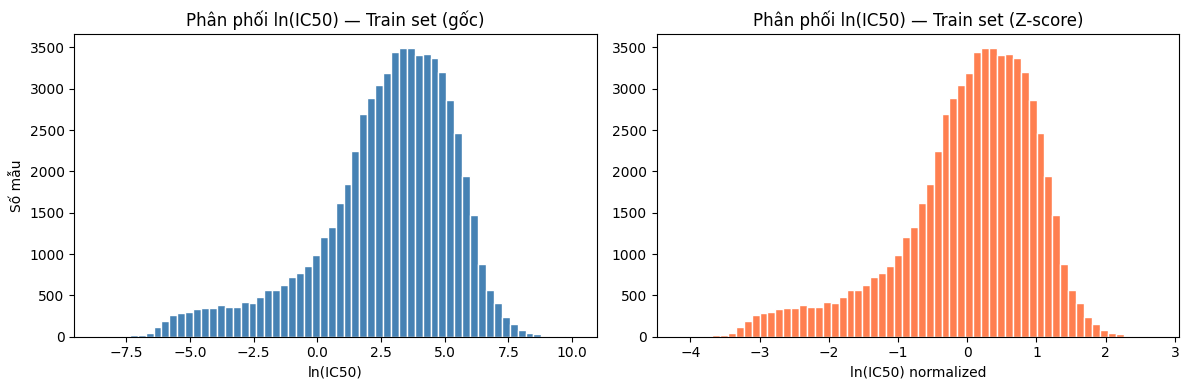

Drug: 137 | Cell: 563 | Pairs: 64,778


In [4]:
# ============================================================
#  CELL 4 — EDA NHANH: PHÂN PHỐI NHÃN ln(IC50)
# ============================================================
import matplotlib.pyplot as plt

assert 'df_train' in dir(), "❌ Chạy Cell 3 trước."

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram ln(IC50) gốc (trước normalize)
axes[0].hist(df_train['Y'] * TARGET_STD + TARGET_MEAN, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Phân phối ln(IC50) — Train set (gốc)')
axes[0].set_xlabel('ln(IC50)')
axes[0].set_ylabel('Số mẫu')

# Histogram sau normalize
axes[1].hist(df_train['Y'], bins=60, color='coral', edgecolor='white')
axes[1].set_title('Phân phối ln(IC50) — Train set (Z-score)')
axes[1].set_xlabel('ln(IC50) normalized')

plt.tight_layout()
plt.show()
print(f"Drug: {df_train[DRUG_ID_COL].nunique()} | Cell: {df_train[CELL_ID_COL].nunique()} | Pairs: {len(df_train):,}")


In [5]:
# ============================================================
#  CELL 5 — ĐẶC TRƯNG TẾ BÀO: GENE EXPRESSION TỪ TDC
#  Nguồn: Cột 'X2' trong gdsc2.pkl (17737-dim numpy array/list)
#  Xử lý: StandardScaler fit trên Train → Top-K genes có variance cao nhất
# ============================================================

assert 'df_train' in dir(), "❌ Chạy Cell 3 trước."

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("       ĐẶC TRƯNG TẾ BÀO — GENE EXPRESSION (PyTDC)")
print("=" * 60)

# ── Cấu hình ─────────────────────────────────────────────────────
K_GENES = 512   # Top-K genes có variance cao nhất trên tập train
                # Có thể thử: 256, 512, 1024

# ── Bước 1: Lấy tất cả cell lines duy nhất trong 3 tập ───────────
all_dfs = pd.concat([df_train, df_val, df_test], ignore_index=True)
unique_cells_df = all_dfs.drop_duplicates(subset=CELL_ID_COL)[[CELL_ID_COL, GE_COL]]

print(f"Tổng cell lines duy nhất : {len(unique_cells_df):,}")

# ── Bước 2: Xây dựng ma trận GE từ cột 'X2' ─────────────────────
# X2 có thể là list hoặc numpy array → ép về float32 nhất quán
print("Đang xây dựng ma trận GE...")
all_cell_ids_list = unique_cells_df[CELL_ID_COL].values
all_cell_ge = np.array(
    [np.array(v, dtype=np.float32) for v in unique_cells_df[GE_COL].values]
)
print(f"  → Ma trận GE thô: {all_cell_ge.shape}  (cells × genes)")

# ── Bước 3: Xác định mask cho tập Train ─────────────────────────
train_cell_ids_set = set(df_train[CELL_ID_COL])
train_mask = np.array([cid in train_cell_ids_set for cid in all_cell_ids_list])
train_ge   = all_cell_ge[train_mask]
print(f"  → Train cells    : {train_mask.sum():,} / {len(train_mask):,}")

# ── Bước 4: Fit StandardScaler trên Train → Transform tất cả ─────
print(f"\nFit StandardScaler trên {train_ge.shape[0]} train cells...")
scaler_ge = StandardScaler()
scaler_ge.fit(train_ge)
all_cell_ge_scaled = scaler_ge.transform(all_cell_ge).astype(np.float32)
train_ge_scaled    = all_cell_ge_scaled[train_mask]

# ── Bước 5: Chọn Top-K genes có variance cao nhất (fit trên Train) ─
print(f"Chọn Top-{K_GENES} genes có variance cao nhất trên train...")
gene_variances = np.var(train_ge_scaled, axis=0)       # (17737,)
top_k_indices  = np.argsort(gene_variances)[-K_GENES:] # Indices của K genes lớn nhất

# Lọc chỉ giữ K genes được chọn
all_cell_ge_topk = all_cell_ge_scaled[:, top_k_indices]  # (n_cells, K)
CELL_FEAT_DIM    = K_GENES

var_captured = gene_variances[top_k_indices].sum() / gene_variances.sum()
print(f"  → Đã chọn {CELL_FEAT_DIM} genes (top {K_GENES} theo variance trên train)")
print(f"  → Variance được giữ lại: {var_captured:.1%} so với tổng")

# ── Bước 6: Xây dựng cell_feat_dict ─────────────────────────────
cell_feat_dict = dict(zip(all_cell_ids_list, all_cell_ge_topk))

print(f"\n✅ cell_feat_dict: {len(cell_feat_dict):,} entries | dim = {CELL_FEAT_DIM}")
print(f"   Sample: {all_cell_ids_list[0]} → shape={all_cell_ge_topk[0].shape}")
print("=" * 60)


       ĐẶC TRƯNG TẾ BÀO — GENE EXPRESSION (PyTDC)
Tổng cell lines duy nhất : 805
Đang xây dựng ma trận GE...
  → Ma trận GE thô: (805, 17737)  (cells × genes)
  → Train cells    : 563 / 805

Fit StandardScaler trên 563 train cells...
Chọn Top-512 genes có variance cao nhất trên train...
  → Đã chọn 512 genes (top 512 theo variance trên train)
  → Variance được giữ lại: 2.9% so với tổng

✅ cell_feat_dict: 805 entries | dim = 512
   Sample: HCC1954 → shape=(512,)


In [6]:
# ============================================================
#  CELL 6 (REVISED) — SMILES → MOLECULAR GRAPH + ECFP4 FINGERPRINT
#  Thay thế hoàn toàn Cell 6 cũ.
#
#  Cải thiện so với bản gốc:
#   1. Giữ nguyên việc build molecular graph (GCNConv input)
#   2. THÊM Morgan ECFP4 fingerprint (2048-bit) cho mỗi thuốc
#      → lưu vào drug_fp_cache (dùng ở Cell 7 + Cell 9)
#   3. drug_graph_cache vẫn giữ như cũ (tương thích Cell 7)
#   4. Khớp Mordred descriptors từ IMPROVE bằng cách chuẩn hóa SMILES
# ============================================================

assert 'df_train' in dir(), "❌ Chạy Cell 3 trước."
assert 'cell_feat_dict' in dir(), "❌ Chạy Cell 5 trước."

import torch
import numpy as np
import pandas as pd
from torch_geometric.data import Data
from rdkit import Chem
from rdkit.Chem import AllChem
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("       SMILES → MOLECULAR GRAPH + ECFP4 FINGERPRINT")
print("=" * 60)

# ── Config ───────────────────────────────────────────────────────
FP_RADIUS = 2       # Morgan radius (ECFP4 = radius 2)
FP_NBITS  = 2048    # Fingerprint bit length

# ── Load drug SMILES ─────────────────────────────────────────────
# THÊM: Lấy SMILES trực tiếp từ TDC DataFrame (cột X1)
df_smiles = (
    pd.concat([df_train, df_val, df_test], ignore_index=True)
      [[DRUG_ID_COL, SMILES_COL]]
      .drop_duplicates(subset=DRUG_ID_COL)
)
drug_smiles_dict = dict(zip(df_smiles[DRUG_ID_COL], df_smiles[SMILES_COL]))
print(f"Drug SMILES loaded: {len(drug_smiles_dict):,}")

# ── Xác định drugs cần parse ─────────────────────────────────────
all_drug_ids  = (set(df_train[DRUG_ID_COL]) |
                 set(df_val[DRUG_ID_COL])   |
                 set(df_test[DRUG_ID_COL]))
drugs_to_parse = all_drug_ids  # Tất cả drugs đều có SMILES trong TDC

print(f"Drugs trong splits  : {len(all_drug_ids):,}")
print(f"Drugs cần parse     : {len(drugs_to_parse):,}  (100% có SMILES)")
print()

# ── Atom / Bond feature functions (giữ nguyên từ Cell 6 gốc) ─────
HYBRIDIZATION_LIST = [
    Chem.rdchem.HybridizationType.S,
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]
BOND_TYPE_LIST = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]

def atom_features(atom):
    """Node feature vector (11-dim). Giữ nguyên từ bản gốc."""
    hyb_one_hot = [int(atom.GetHybridization() == h) for h in HYBRIDIZATION_LIST]
    return [
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        *hyb_one_hot,
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ]  # 11-dim

def bond_features(bond):
    """Edge feature vector (4-dim). Giữ nguyên từ bản gốc."""
    return [int(bond.GetBondType() == bt) for bt in BOND_TYPE_LIST]

def smiles_to_graph(smiles):
    """SMILES -> torch_geometric.data.Data | None. Giữ nguyên từ bản gốc."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None or mol.GetNumAtoms() == 0:
            return None
        x = [atom_features(a) for a in mol.GetAtoms()]
        x = torch.tensor(x, dtype=torch.float)
        edge_indices, edge_attrs = [], []
        for bond in mol.GetBonds():
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            bf = bond_features(bond)
            edge_indices.extend([[i, j], [j, i]])
            edge_attrs.extend([bf, bf])
        if edge_indices:
            edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
            edge_attr  = torch.tensor(edge_attrs,   dtype=torch.float)
        else:
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            edge_attr  = torch.zeros((0, 4), dtype=torch.float)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    except Exception:
        return None

def smiles_to_ecfp4(smiles, n_bits=FP_NBITS, radius=FP_RADIUS):
    """
    SMILES -> Morgan ECFP4 fingerprint (numpy array, float32).
    Trả về np.zeros nếu parse lỗi (để không drop thuốc chỉ vì fingerprint).
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.zeros(n_bits, dtype=np.float32)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
        return np.array(fp, dtype=np.float32)
    except Exception:
        return np.zeros(n_bits, dtype=np.float32)

# ── Parse drugs ──────────────────────────────────────────────────
drug_graph_cache = {}   # drug_id -> Data | None  (graph cho GCN)
drug_fp_cache    = {}   # drug_id -> np.array     (fingerprint 2048-dim)

invalid_graphs = []
zero_fp_count  = 0
total_nodes, total_edges = 0, 0

for drug_id in tqdm(drugs_to_parse, desc="SMILES -> Graph + FP"):
    smiles = drug_smiles_dict[drug_id]

    # --- Molecular graph ---
    graph = smiles_to_graph(smiles)
    drug_graph_cache[drug_id] = graph
    if graph is None:
        invalid_graphs.append(drug_id)
    else:
        total_nodes += graph.x.shape[0]
        total_edges += graph.edge_index.shape[1]

    # --- ECFP4 Fingerprint ---
    fp = smiles_to_ecfp4(smiles)
    drug_fp_cache[drug_id] = fp
    if fp.sum() == 0:
        zero_fp_count += 1

n_valid = len(drug_graph_cache) - len(invalid_graphs)

print()
print("=" * 60)
print("  MOLECULAR GRAPH")
print(f"  [OK] Valid graphs     : {n_valid:,}")
print(f"  [FAIL] Invalid SMILES   : {len(invalid_graphs):,}")
if invalid_graphs:
    for did in invalid_graphs[:3]:
        print(f"     {did}: {drug_smiles_dict.get(did, '?')[:50]}")
print(f"  Avg nodes/graph    : {total_nodes / max(n_valid, 1):.1f}")
print(f"  Avg edges/graph    : {total_edges / max(n_valid, 1):.1f}")

print()
print("  ECFP4 FINGERPRINT (Morgan radius=2, bits=2048)")
print(f"  [OK] FP computed      : {len(drug_fp_cache):,}")
print(f"  [WARN] Zero FP (fallback): {zero_fp_count:,}")

# ── Verify sample ─────────────────────────────────────────────────
sample_did = next(d for d, g in drug_graph_cache.items() if g is not None)
sg  = drug_graph_cache[sample_did]
sfp = drug_fp_cache[sample_did]

print()
print(f"  Sample drug ({sample_did}):")
print(f"    Graph: x={sg.x.shape}, edge_index={sg.edge_index.shape}")
print(f"    FP   : shape={sfp.shape}, bits on={int(sfp.sum())}/{FP_NBITS}")
print(f"    Tanimoto density: {sfp.mean():.3f}")
print("=" * 60)

# ── Load Mordred Descriptors ─────────────────────────────────────
print("\n  MORDRED DESCRIPTORS (Từ file của IMPROVE)")
BASE_IMPROVE = "/kaggle/input/datasets/ducer37/improve/csa_data/csa_data/raw_data"
df_mordred = pd.read_csv(f"{BASE_IMPROVE}/x_data/drug_mordred.tsv", sep='\t')

# Bỏ cột ID, biến đổi mọi thứ thành dạng số
mordred_cols = [c for c in df_mordred.columns if c != 'improve_chem_id']
for c in mordred_cols:
    df_mordred[c] = pd.to_numeric(df_mordred[c], errors='coerce')

# Fill NaN bằng median của cột, nếu vẫn còn NaN thì fill bằng 0
df_mordred[mordred_cols] = df_mordred[mordred_cols].fillna(df_mordred[mordred_cols].median()).fillna(0)

# Định nghĩa hàm chuẩn hóa SMILES để so khớp
def canonicalize_smiles(s):
    try:
        mol = Chem.MolFromSmiles(s)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
    except:
        pass
    return s

# Load bảng SMILES của IMPROVE để lấy mapping (standard_SMILES -> improve_chem_id)
df_improve_smiles = pd.read_csv(f"{BASE_IMPROVE}/x_data/drug_SMILES.tsv", sep='\t')
df_improve_smiles['std_smiles'] = df_improve_smiles['canSMILES'].apply(canonicalize_smiles)
smiles_to_chem_id = dict(zip(df_improve_smiles['std_smiles'], df_improve_smiles['improve_chem_id']))

# Phân tách tập Train Drugs
train_drugs_set = set(df_train[DRUG_ID_COL])
train_smiles_std = [canonicalize_smiles(drug_smiles_dict[d]) for d in train_drugs_set]
train_chem_ids = [smiles_to_chem_id[s] for s in train_smiles_std if s in smiles_to_chem_id]

# Fit StandardScaler chỉ trên các train drugs này
scaler_mordred = StandardScaler()
mordred_train_sub = df_mordred[df_mordred['improve_chem_id'].isin(train_chem_ids)][mordred_cols].values

if len(mordred_train_sub) > 0:
    print(f"  Fit StandardScaler trên {len(mordred_train_sub)} train drugs...")
    scaler_mordred.fit(mordred_train_sub)
    scaled_mordred = scaler_mordred.transform(df_mordred[mordred_cols].values).astype(np.float32)
else:
    print("  [WARN] Không tìm thấy train drugs trùng khớp trong IMPROVE! Fit trên toàn bộ.")
    scaler_mordred.fit(df_mordred[mordred_cols].values)
    scaled_mordred = scaler_mordred.transform(df_mordred[mordred_cols].values).astype(np.float32)

chem_id_to_mordred = dict(zip(df_mordred['improve_chem_id'], scaled_mordred))
MORDRED_DIM = len(mordred_cols)

# Map ngược lại cache cho drug_id (ID1) bằng chuẩn hóa SMILES
drug_mordred_cache = {}
for drug_id in drugs_to_parse:
    smiles = drug_smiles_dict[drug_id]
    std_s = canonicalize_smiles(smiles)
    chem_id = smiles_to_chem_id.get(std_s)
    if chem_id and chem_id in chem_id_to_mordred:
        drug_mordred_cache[drug_id] = chem_id_to_mordred[chem_id]

# Tạo mảng zeros cho các drug bị thiếu Mordred
zero_mordred = np.zeros(MORDRED_DIM, dtype=np.float32)
missing_mordred = sum(1 for d in drugs_to_parse if d not in drug_mordred_cache)

print(f"  [OK] Mordred mapped   : {len(drug_mordred_cache):,} drugs ({MORDRED_DIM}-dim)")
print(f"  [WARN] Thiếu Mordred    : {missing_mordred:,} (sử dụng zero padding)")


       SMILES → MOLECULAR GRAPH + ECFP4 FINGERPRINT
Drug SMILES loaded: 137
Drugs trong splits  : 137
Drugs cần parse     : 137  (100% có SMILES)



SMILES -> Graph + FP:   0%|          | 0/137 [00:00<?, ?it/s][18:19:19] DEPRECATION WARNING: please use MorganGenerator
[18:19:19] DEPRECATION WARNING: please use MorganGenerator
[18:19:19] DEPRECATION WARNING: please use MorganGenerator
[18:19:19] DEPRECATION WARNING: please use MorganGenerator
[18:19:19] DEPRECATION WARNING: please use MorganGenerator
[18:19:19] DEPRECATION WARNING: please use MorganGenerator
[18:19:19] DEPRECATION WARNING: please use MorganGenerator
[18:19:20] DEPRECATION WARNING: please use MorganGenerator
[18:19:20] DEPRECATION WARNING: please use MorganGenerator
[18:19:20] DEPRECATION WARNING: please use MorganGenerator
[18:19:20] DEPRECATION WARNING: please use MorganGenerator
[18:19:20] DEPRECATION WARNING: please use MorganGenerator
[18:19:20] DEPRECATION WARNING: please use MorganGenerator
[18:19:20] DEPRECATION WARNING: please use MorganGenerator
[18:19:20] DEPRECATION WARNING: please use MorganGenerator
[18:19:20] DEPRECATION WARNING: please use MorganGener


  MOLECULAR GRAPH
  [OK] Valid graphs     : 137
  [FAIL] Invalid SMILES   : 0
  Avg nodes/graph    : 32.0
  Avg edges/graph    : 70.4

  ECFP4 FINGERPRINT (Morgan radius=2, bits=2048)
  [OK] FP computed      : 137
  [WARN] Zero FP (fallback): 0

  Sample drug (Daporinad):
    Graph: x=torch.Size([29, 11]), edge_index=torch.Size([2, 62])
    FP   : shape=(2048,), bits on=54/2048
    Tanimoto density: 0.026

  MORDRED DESCRIPTORS (Từ file của IMPROVE)


[18:19:22] WARNING: not removing hydrogen atom without neighbors
[18:19:22] WARNING: not removing hydrogen atom without neighbors
[18:19:22] WARNING: not removing hydrogen atom without neighbors


  Fit StandardScaler trên 98 train drugs...
  [OK] Mordred mapped   : 98 drugs (1613-dim)
  [WARN] Thiếu Mordred    : 39 (sử dụng zero padding)


In [7]:
# ============================================================
#  CELL 7 (REVISED) — TẠO DATASET + STRICT FILTER
#  Thay thế Cell 7 cũ.
#
#  Thay đổi so với bản gốc:
#   - Thêm drug_fp (ECFP4) vào mỗi Data object
#   - Cập nhật CELL_FEAT_DIM_TOTAL (thay vì cứng 512)
#   - Strict filter bao gồm kiểm tra drug_fp_cache
#   - Đổi tên biến: auc_value -> y_value (ln IC50)
# ============================================================

assert 'drug_graph_cache' in dir(), "❌ Chạy Cell 6 trước."
assert 'drug_fp_cache'    in dir(), "❌ Chạy Cell 6 trước."
assert 'cell_feat_dict'   in dir(), "❌ Chạy Cell 5 trước."
assert 'df_train'         in dir(), "❌ Chạy Cell 3 trước."

import torch
import numpy as np
import pandas as pd
from torch_geometric.data import Data
from tqdm import tqdm

print("=" * 60)
print("       TẠO DATASET + STRICT FILTER (với FP)")
print("=" * 60)

def create_data_object(row):
    """
    Tạo 1 Data object từ 1 row.
    Bổ sung: drug_fp từ drug_fp_cache.
    """
    drug_id   = row[DRUG_ID_COL]
    cell_id   = row[CELL_ID_COL]
    y_value   = row[TARGET_COL]  # ln(IC50) đã normalized
    graph     = drug_graph_cache[drug_id]
    cell_feat = cell_feat_dict[cell_id]
    drug_fp   = drug_fp_cache[drug_id]
    
    # Lấy Mordred an toàn (nếu thiếu thì dùng vector 0)
    mordred_feat = drug_mordred_cache.get(drug_id, zero_mordred)
    data = Data(
        x            = graph.x.clone(),
        edge_index   = graph.edge_index.clone(),
        edge_attr    = graph.edge_attr.clone(),
        cell_feat    = torch.tensor(cell_feat, dtype=torch.float).unsqueeze(0),
        drug_fp      = torch.tensor(drug_fp, dtype=torch.float).unsqueeze(0),
        drug_mordred = torch.tensor(mordred_feat, dtype=torch.float).unsqueeze(0),
        y            = torch.tensor([y_value], dtype=torch.float),
    )
    return data

def build_dataset(df_split, split_name):
    """Filter + tạo Data objects cho 1 split."""
    data_list      = []
    n_drug_drop    = 0
    n_cell_drop    = 0
    n_target_drop  = 0

    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc=f"Building {split_name}"):
        drug_id = row[DRUG_ID_COL]
        cell_id = row[CELL_ID_COL]
        y_val   = row[TARGET_COL]

        # 1. Check drug graph valid
        if drug_id not in drug_graph_cache or drug_graph_cache[drug_id] is None:
            n_drug_drop += 1
            continue

        # 2. Check drug FP valid
        if drug_id not in drug_fp_cache:
            n_drug_drop += 1
            continue

        # 3. Check cell feature valid
        if cell_id not in cell_feat_dict:
            n_cell_drop += 1
            continue

        # 4. Check target value valid
        if pd.isna(y_val):
            n_target_drop += 1
            continue

        # Đạt mọi tiêu chuẩn → Tạo Data object
        data_obj = create_data_object(row)
        data_list.append(data_obj)

    print(f"  Completed: {split_name}")
    print(f"    - Thành công : {len(data_list):,} / {len(df_split):,}")
    print(f"    - Bỏ qua do Drug : {n_drug_drop:,}")
    print(f"    - Bỏ qua do Cell : {n_cell_drop:,}")
    print(f"    - Bỏ qua do Nhãn : {n_target_drop:,}")
    print()
    return data_list

# ── Thực thi build dataset ──────────────────────────────────────
data_train = build_dataset(df_train, "Train Set")
data_val   = build_dataset(df_val,   "Val Set")
data_test  = build_dataset(df_test,  "Test Set")

# ── Kích thước các feature ───────────────────────────────────────
NODE_FEAT_DIM = data_train[0].x.shape[1]
CELL_FEAT_DIM = data_train[0].cell_feat.shape[1]  # Đọc động từ cell_feat (chỉ số 1 là chiều đặc trưng)
FP_DIM        = data_train[0].drug_fp.shape[1]    # Đọc động từ drug_fp
MORDRED_DIM   = data_train[0].drug_mordred.shape[1]

print("=" * 60)
print("  DATASET STATISTICS")
print("=" * 60)
print(f"  Train samples: {len(data_train):,}")
print(f"  Val samples  : {len(data_val):,}")
print(f"  Test samples : {len(data_test):,}")
print()
print(f"  NODE_FEAT_DIM (Graph)  : {NODE_FEAT_DIM}")
print(f"  CELL_FEAT_DIM (Top-K)  : {CELL_FEAT_DIM}")
print(f"  FP_DIM        (ECFP4)  : {FP_DIM}")
print(f"  MORDRED_DIM   (Mordred): {MORDRED_DIM}")
print("=" * 60)


       TẠO DATASET + STRICT FILTER (với FP)


Building Train Set: 100%|██████████| 64778/64778 [00:16<00:00, 3944.69it/s]


  Completed: Train Set
    - Thành công : 64,778 / 64,778
    - Bỏ qua do Drug : 0
    - Bỏ qua do Cell : 0
    - Bỏ qua do Nhãn : 0



Building Val Set: 100%|██████████| 9694/9694 [00:02<00:00, 3383.16it/s]


  Completed: Val Set
    - Thành công : 9,694 / 9,694
    - Bỏ qua do Drug : 0
    - Bỏ qua do Cell : 0
    - Bỏ qua do Nhãn : 0



Building Test Set: 100%|██████████| 18231/18231 [00:04<00:00, 3706.17it/s]

  Completed: Test Set
    - Thành công : 18,231 / 18,231
    - Bỏ qua do Drug : 0
    - Bỏ qua do Cell : 0
    - Bỏ qua do Nhãn : 0

  DATASET STATISTICS
  Train samples: 64,778
  Val samples  : 9,694
  Test samples : 18,231

  NODE_FEAT_DIM (Graph)  : 11
  CELL_FEAT_DIM (Top-K)  : 512
  FP_DIM        (ECFP4)  : 2048
  MORDRED_DIM   (Mordred): 1613


In [8]:
assert 'data_train' in dir(), "❌ Chạy Cell 7 trước."
from torch_geometric.loader import DataLoader
print("=" * 60)
print("       DATALOADER")
print("=" * 60)
train_loader = DataLoader(data_train, batch_size=64,  shuffle=True)
val_loader   = DataLoader(data_val,   batch_size=128, shuffle=False)
test_loader  = DataLoader(data_test,  batch_size=128, shuffle=False)
print(f"Train : {len(train_loader):,} batches (bs=64)")
print(f"Val   : {len(val_loader):,} batches (bs=128)")
print(f"Test  : {len(test_loader):,} batches (bs=128)")
print()
batch = next(iter(train_loader))
print("--- Batch mẫu (train) ---")
print(f"  batch.x          : {batch.x.shape}")
print(f"  batch.edge_index : {batch.edge_index.shape}")
print(f"  batch.edge_attr  : {batch.edge_attr.shape}")
print(f"  batch.batch      : {batch.batch.shape} (graphs: {batch.batch.max().item()+1})")
print(f"  batch.cell_feat  : {batch.cell_feat.shape}")
print(f"  batch.y          : {batch.y.shape}")
print("=" * 60)

       DATALOADER
Train : 1,013 batches (bs=64)
Val   : 76 batches (bs=128)
Test  : 143 batches (bs=128)

--- Batch mẫu (train) ---
  batch.x          : torch.Size([2036, 11])
  batch.edge_index : torch.Size([2, 4476])
  batch.edge_attr  : torch.Size([4476, 4])
  batch.batch      : torch.Size([2036]) (graphs: 64)
  batch.cell_feat  : torch.Size([64, 512])
  batch.y          : torch.Size([64])


In [9]:
# ============================================================
#  CELL 9 (REVISED) — MODEL GraphCDR + FP ENCODER
#  Thay thế Cell 9 cũ.
#
#  Thay đổi so với bản gốc:
#   1. GraphCDR thêm fp_encoder: Linear(FP_NBITS → fp_out=64)
#   2. fusion nhận [drug_repr(128) | fp_repr(64) | cell_repr(128)]
#      → tổng input 320-dim thay vì 256-dim
#   3. CELL_FEAT_DIM đọc từ data_train[0] (tự động nhận multi-omics)
#   4. FP_DIM đọc từ data_train[0].drug_fp (tự động)
#   5. Mọi thứ khác (DrugEncoder, CellEncoder, augmentation,
#      NT-Xent loss) giữ NGUYÊN từ bản gốc
# ============================================================

assert 'train_loader' in dir(), "❌ Chạy Cell 8 trước."
assert 'data_train'   in dir(), "❌ Chạy Cell 7 trước."

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv, GINEConv, global_mean_pool, global_max_pool
from torch_geometric.data import Data

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("       MODEL GraphCDR + FP ENCODER")
print("=" * 60)
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
print()

# Đọc dims từ data (tự động nhận đúng kích thước)
NODE_FEAT_DIM = data_train[0].x.shape[1]               # 11
CELL_FEAT_DIM = data_train[0].cell_feat.shape[1]        # multi-omics total dim
FP_DIM        = data_train[0].drug_fp.shape[1]          # 2048 (ECFP4)
MORDRED_DIM   = data_train[0].drug_mordred.shape[1]   # ← THÊM MỚI

print(f"Node feat dim  : {NODE_FEAT_DIM}  (atom features)")
print(f"Cell feat dim  : {CELL_FEAT_DIM}  (multi-omics)")
print(f"Drug FP dim    : {FP_DIM}  (ECFP4 fingerprint)")
print()

# ============================================================
# Augmentation: DropNode (GIỐNG HỆT bản gốc)
# ============================================================
def augment_graph(batch, drop_rate=0.1):
    """DropNode augmentation trên batched graph."""
    num_nodes = batch.x.size(0)
    keep_mask = torch.rand(num_nodes, device=batch.x.device) > drop_rate

    for g_idx in range(batch.batch.max().item() + 1):
        graph_mask = (batch.batch == g_idx)
        if (keep_mask & graph_mask).sum() == 0:
            first_node = graph_mask.nonzero(as_tuple=True)[0][0]
            keep_mask[first_node] = True

    node_mapping = torch.full((num_nodes,), -1, dtype=torch.long, device=batch.x.device)
    kept_indices = keep_mask.nonzero(as_tuple=True)[0]
    node_mapping[kept_indices] = torch.arange(kept_indices.size(0), device=batch.x.device)

    ei = batch.edge_index
    edge_keep      = keep_mask[ei[0]] & keep_mask[ei[1]]
    new_edge_index = node_mapping[ei[:, edge_keep]]
    new_edge_attr  = batch.edge_attr[edge_keep] if batch.edge_attr is not None else None

    if new_edge_index.size(1) == 0:
        return batch
    aug_data       = Data(x=batch.x[keep_mask], edge_index=new_edge_index, edge_attr=new_edge_attr)
    aug_data.batch = batch.batch[keep_mask]
    return aug_data

# ============================================================
# NT-Xent Contrastive Loss (GIỐNG HỆT bản gốc)
# ============================================================
def nt_xent_loss(z1, z2, temperature=0.5):
    """NT-Xent loss. z1, z2: [B, dim]."""
    B = z1.size(0)
    if B < 2:
        return torch.tensor(0.0, device=z1.device)
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    z  = torch.cat([z1, z2], dim=0)
    N  = z.size(0)
    sim  = torch.mm(z, z.t()) / temperature
    mask = ~torch.eye(N, dtype=torch.bool, device=z.device)
    idx  = torch.arange(B, device=z.device)
    pos1 = sim[idx, idx + B]
    pos2 = sim[idx + B, idx]
    denom1 = sim[idx].masked_select(mask[idx]).view(B, N - 1)
    denom2 = sim[idx + B].masked_select(mask[idx + B]).view(B, N - 1)
    loss = ((-pos1 + torch.logsumexp(denom1, dim=1)) +
            (-pos2 + torch.logsumexp(denom2, dim=1))).mean() / 2
    return loss

# ============================================================
# DrugEncoder — GIỐNG HỆT bản gốc
# ============================================================
class DrugEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, edge_dim=4, heads=2):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden_dim // heads, heads=heads, edge_dim=edge_dim)
        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, edge_dim=edge_dim)
        self.conv3 = GATv2Conv(hidden_dim, out_dim // heads, heads=heads, edge_dim=edge_dim)
        self.ln1, self.ln2, self.ln3 = nn.LayerNorm(hidden_dim), nn.LayerNorm(hidden_dim), nn.LayerNorm(out_dim)
    def forward(self, x, edge_index, edge_attr, batch):
        x = F.relu(self.ln1(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.ln2(self.conv2(x, edge_index, edge_attr)))
        x = F.relu(self.ln3(self.conv3(x, edge_index, edge_attr)))
        return global_max_pool(x, batch)

# ============================================================
# CellEncoder — GIỐNG HỆT bản gốc
# (nhận CELL_FEAT_DIM động, tự động scale với multi-omics)
# ============================================================
class CellEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)

# ============================================================
# GraphCDR — THAY ĐỔI CHÍNH
# Thêm fp_encoder branch (3 dòng trong __init__, 2 dòng trong forward)
# ============================================================
class GraphCDR(nn.Module):
    def __init__(self, node_feat_dim, cell_feat_dim,
                 fp_dim=2048,           # ← THÊM MỚI
                 mordred_dim=1613, 
                 gcn_hidden=256, drug_out=128,
                 cell_hidden=512, cell_out=128,
                 fp_out=64, mordred_out=64,             
                 fusion_hidden=128, dropout=0.107):
        super().__init__()

        self.drug_encoder = DrugEncoder(node_feat_dim, gcn_hidden, drug_out)
        self.cell_encoder = CellEncoder(cell_feat_dim, cell_hidden, cell_out, dropout)

        # ── FP Encoder (THÊM MỚI) ────────────────────────────────
        # Map ECFP4 2048-bit → fp_out (64-dim compact representation)
        self.fp_encoder = nn.Sequential(
            nn.Linear(fp_dim, fp_out * 4),   # 2048 → 256
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fp_out * 4, fp_out),   # 256 → 64
            nn.ReLU(),
        )

        # ── Mordred Encoder (THÊM MỚI) ───────────────────────────
        self.mordred_encoder = nn.Sequential(
            nn.Linear(mordred_dim, mordred_out * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mordred_out * 4, mordred_out),
            nn.ReLU(),
        )

        # ── Fusion (drug_out + fp_out + mordred_out + cell_out) ──
        # 128 + 64 + 64 + 128 = 384
        fusion_in = drug_out + fp_out + mordred_out + cell_out
        self.fusion = nn.Sequential(
            nn.Linear(fusion_in, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, 1),
        )
    def forward(self, batch):
        # 1. Khử toàn bộ NaN/Inf
        batch.cell_feat = torch.nan_to_num(batch.cell_feat, nan=0.0, posinf=0.0, neginf=0.0)
        batch.drug_mordred = torch.nan_to_num(batch.drug_mordred, nan=0.0, posinf=0.0, neginf=0.0)
        batch.drug_fp = torch.nan_to_num(batch.drug_fp, nan=0.0, posinf=0.0, neginf=0.0)
        batch.x = torch.nan_to_num(batch.x, nan=0.0, posinf=0.0, neginf=0.0)
        
        # 2. Xử lý như bình thường (Giữ nguyên các hàm squeeze của bạn)
        drug_repr = self.drug_encoder(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        
        cell_feat = batch.cell_feat.squeeze(1)                                  
        cell_repr = self.cell_encoder(cell_feat)                                
        
        fp_feat   = batch.drug_fp.squeeze(1)                                    
        fp_repr   = self.fp_encoder(fp_feat)                                    
        
        mordred_feat = batch.drug_mordred.squeeze(1)                            
        mordred_repr = self.mordred_encoder(mordred_feat)                       
        
        combined  = torch.cat([drug_repr, fp_repr, mordred_repr, cell_repr], dim=1) 
        pred      = self.fusion(combined)                                       
        return pred, drug_repr
    def encode_drug(self, batch):
        batch.x = torch.nan_to_num(batch.x, nan=0.0, posinf=0.0, neginf=0.0)
        return self.drug_encoder(batch.x, batch.edge_index, batch.edge_attr, batch.batch)

# ── Khởi tạo ─────────────────────────────────────────────────────
model = GraphCDR(
    node_feat_dim = NODE_FEAT_DIM,
    cell_feat_dim = CELL_FEAT_DIM,   # tự động nhận multi-omics dim
    fp_dim        = FP_DIM,          # tự động nhận ECFP4 dim
    mordred_dim   = MORDRED_DIM,
).to(DEVICE)

# ── Thống kê params ───────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Chi tiết từng module
def count_params(module):
    return sum(p.numel() for p in module.parameters())

print("--- Model architecture ---")
print(model)
print()
print(f"{'Module':20s} {'Params':>10s}")
print("-" * 32)
print(f"{'DrugEncoder (GCN)':20s} {count_params(model.drug_encoder):>10,}")
print(f"{'FP Encoder (MLP)':20s} {count_params(model.fp_encoder):>10,}  ← mới")
print(f"{'CellEncoder (MLP)':20s} {count_params(model.cell_encoder):>10,}")
print(f"{'Fusion':20s} {count_params(model.fusion):>10,}")
print("-" * 32)
print(f"{'TOTAL':20s} {total_params:>10,}")
print()

# ── Verify forward pass ───────────────────────────────────────────
with torch.no_grad():
    sb = next(iter(train_loader)).to(DEVICE)
    pred, drug_repr = model(sb)
    print(f"✅ Forward OK:")
    print(f"   batch.cell_feat : {sb.cell_feat.shape}")
    print(f"   batch.drug_fp   : {sb.drug_fp.shape}")
    print(f"   pred            : {pred.shape}")
    print(f"   drug_repr       : {drug_repr.shape}")
print("=" * 60)

       MODEL GraphCDR + FP ENCODER
Device: cuda
GPU   : Tesla T4

Node feat dim  : 11  (atom features)
Cell feat dim  : 512  (multi-omics)
Drug FP dim    : 2048  (ECFP4 fingerprint)

--- Model architecture ---
GraphCDR(
  (drug_encoder): DrugEncoder(
    (conv1): GATv2Conv(11, 128, heads=2)
    (conv2): GATv2Conv(256, 128, heads=2)
    (conv3): GATv2Conv(256, 64, heads=2)
    (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (ln3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (cell_encoder): CellEncoder(
    (net): Sequential(
      (0): Linear(in_features=512, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.107, inplace=False)
      (3): Linear(in_features=512, out_features=128, bias=True)
    )
  )
  (fp_encoder): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.107, inplace=False)
    (3): Linear(in_featur

       TRAINING GraphCDR
Epochs    : 100
LR        : 0.00010124
Patience  : 20
CL weight : 0.1
Device    : cuda

   Epoch |  Train Loss |  Val RMSE |   Val R |   Time
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


    1/100 |    0.715099 |  0.541583 |  0.8451 |  36.2s ★
    2/100 |    0.584240 |  0.531476 |  0.8520 |  34.5s ★
    3/100 |    0.544126 |  0.531880 |  0.8527 |  34.6s
    4/100 |    0.520689 |  0.532900 |  0.8517 |  34.5s
    5/100 |    0.511398 |  0.525624 |  0.8554 |  34.5s ★
    6/100 |    0.506291 |  0.524275 |  0.8569 |  34.4s ★
    7/100 |    0.504154 |  0.521717 |  0.8574 |  34.4s ★
    8/100 |    0.500870 |  0.521502 |  0.8612 |  34.6s ★
    9/100 |    0.495865 |  0.522457 |  0.8581 |  34.4s
   10/100 |    0.493263 |  0.519254 |  0.8597 |  34.6s ★
   11/100 |    0.493527 |  0.515843 |  0.8611 |  34.6s ★
   12/100 |    0.487957 |  0.516763 |  0.8604 |  34.5s
   13/100 |    0.489280 |  0.523644 |  0.8572 |  34.3s
   14/100 |    0.487930 |  0.517033 |  0.8602 |  34.6s
   15/100 |    0.490032 |  0.517411 |  0.8610 |  34.5s
   16/100 |    0.494163 |  0.518297 |  0.8605 |  34.8s
   17/100 |    0.483686 |  0.519082 |  0.8589 |  34.5s
   18/100 |    0.482930 |  0.518419 |  0.8596 |  

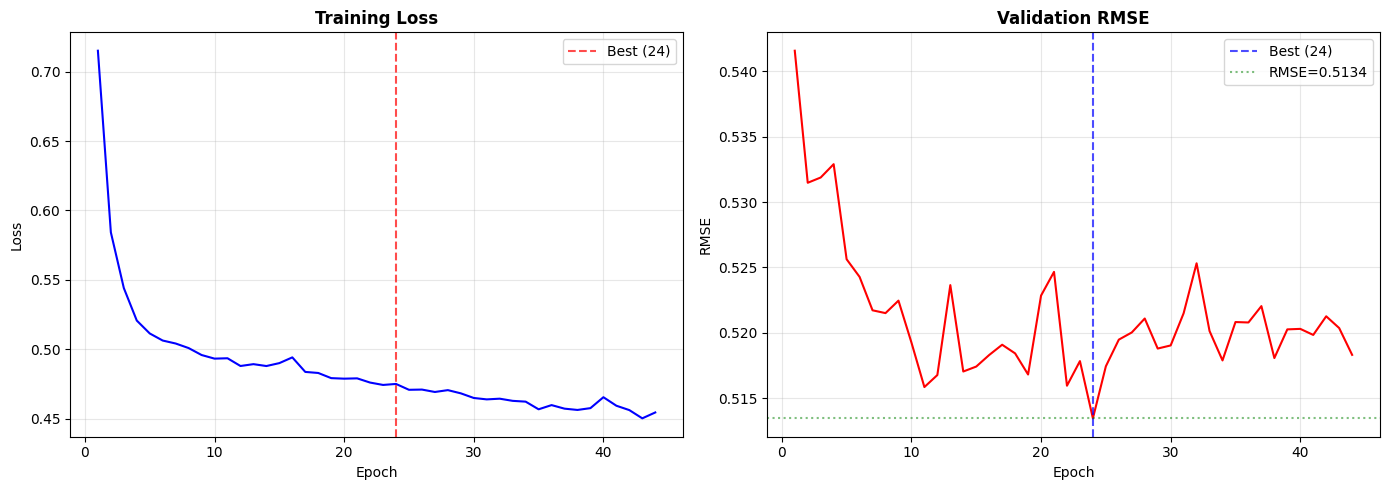

✅ Saved: training_curves_improve.png


In [10]:
assert 'model' in dir(), "❌ Chạy Cell 9 trước."

import time
import numpy as np
from scipy.stats import pearsonr

print("=" * 60)
print("       TRAINING GraphCDR")
print("=" * 60)

EPOCHS             = 100
LR                 = 0.00010124
WEIGHT_DECAY       = 0.0000107
PATIENCE           = 20
CONTRASTIVE_WEIGHT = 0.1
MODEL_PATH         = 'best_model_pytdc.pth'

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
mse_criterion = nn.MSELoss()

print(f"Epochs    : {EPOCHS}")
print(f"LR        : {LR}")
print(f"Patience  : {PATIENCE}")
print(f"CL weight : {CONTRASTIVE_WEIGHT}")
print(f"Device    : {DEVICE}")
print()

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred, drug_repr = model(batch)
        target = torch.nan_to_num(batch.y.squeeze(), nan=0.0, posinf=0.0, neginf=0.0)
        mse_loss = mse_criterion(pred.squeeze(), target)

        cl_loss = torch.tensor(0.0, device=device)
        bs = batch.y.size(0)
        if bs >= 8:
            try:
                aug = augment_graph(batch, drop_rate=0.1).to(device)
                drug_repr_aug = model.encode_drug(aug)
                ms = min(drug_repr.size(0), drug_repr_aug.size(0))
                if ms >= 2:
                    cl_loss = nt_xent_loss(drug_repr[:ms], drug_repr_aug[:ms])
            except Exception:
                cl_loss = torch.tensor(0.0, device=device)

        loss = mse_loss + CONTRASTIVE_WEIGHT * cl_loss

        # ✅ FIX: Kiểm tra NaN TRƯỚC khi backward để bảo vệ trọng số
        if torch.isnan(loss) or torch.isinf(loss):
            continue   # Bỏ qua batch hỏng, KHÔNG backward

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        n += 1
    return total_loss / max(n, 1)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    preds_list, targets_list = [], []
    for batch in loader:
        batch = batch.to(device)
        pred, _ = model(batch)
        preds_list.append(pred.squeeze().cpu().numpy())
        targets_list.append(batch.y.squeeze().cpu().numpy())

    preds   = np.concatenate(preds_list)
    targets = np.concatenate(targets_list)

    # ✅ FIX: Lọc NaN trước khi tính metrics
    mask    = np.isfinite(preds) & np.isfinite(targets)
    preds   = preds[mask]
    targets = targets[mask]

    if len(preds) == 0:
        return {'MSE': np.inf, 'RMSE': np.inf, 'MAE': np.inf, 'R': 0.0,
                'preds': preds, 'targets': targets}

    mse  = np.mean((preds - targets) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(preds - targets))
    r, _ = pearsonr(preds, targets)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R': r,
            'preds': preds, 'targets': targets}


# --- Training loop ---
train_losses, val_rmses = [], []
best_val_rmse = float('inf')
patience_counter = 0
best_epoch = 0

print(f"{'Epoch':>8} | {'Train Loss':>11} | {'Val RMSE':>9} | {'Val R':>7} | {'Time':>6}")
print("-" * 60)

try:
    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_res = evaluate(model, val_loader, DEVICE)
        elapsed = time.time() - t0

        train_losses.append(train_loss)
        val_rmses.append(val_res['RMSE'])

        if val_res['RMSE'] < best_val_rmse:
            best_val_rmse = val_res['RMSE']
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), MODEL_PATH)
            marker = " ★"
        else:
            patience_counter += 1
            marker = ""

        print(f"  {epoch:3d}/{EPOCHS} | {train_loss:11.6f} | {val_res['RMSE']:9.6f} | "
              f"{val_res['R']:7.4f} | {elapsed:5.1f}s{marker}")

        if patience_counter >= PATIENCE:
            print(f"\n⏹  Early stopping at epoch {epoch}")
            break

except KeyboardInterrupt:
    print(f"\n⏸  Interrupted at epoch {epoch}")

print()
print(f"✅ Best: epoch {best_epoch}, Val RMSE = {best_val_rmse:.6f}")
print(f"   Saved: {MODEL_PATH}")
print()

# --- Loss curves ---
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(train_losses)+1), train_losses, 'b-', lw=1.5)
ax1.axvline(best_epoch, color='red', ls='--', alpha=0.7, label=f'Best ({best_epoch})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Training Loss', fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(val_rmses)+1), val_rmses, 'r-', lw=1.5)
ax2.axvline(best_epoch, color='blue', ls='--', alpha=0.7, label=f'Best ({best_epoch})')
ax2.axhline(best_val_rmse, color='green', ls=':', alpha=0.5, label=f'RMSE={best_val_rmse:.4f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('RMSE'); ax2.set_title('Validation RMSE', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_improve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: training_curves_improve.png")
print("=" * 60)


       EVALUATION — TEST SET
✅ Loaded: best_model_pytdc.pth

╔═══════════════════════════════════╗
║       TEST SET RESULTS            ║
╠═══════════════════════════════════╣
║ Samples    :   18,231            ║
║ MSE        :   1.787506          ║
║ RMSE       :   1.336977          ║
║ MAE        :   1.015967          ║
║ R²         :   0.758299          ║
║ Pearson R  :   0.870872 (p=0.0e+00) ║
║ Spearman R :   0.818063 (p=0.0e+00) ║
╚═══════════════════════════════════╝



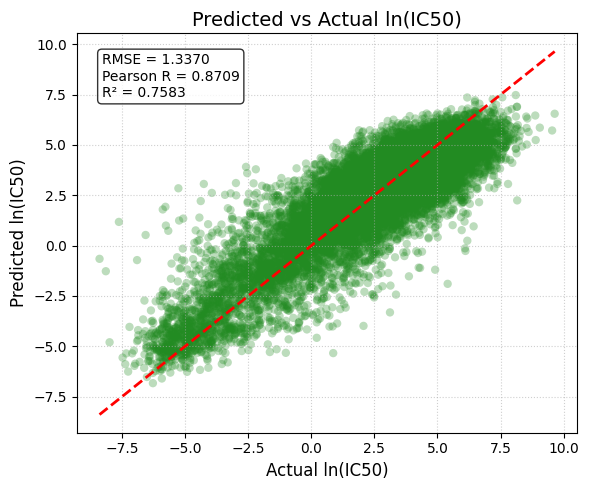

In [11]:
assert 'model' in dir(), "❌ Chạy Cell 9 trước."
assert 'test_loader' in dir(), "❌ Chạy Cell 8 trước."
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score
print("=" * 60)
print("       EVALUATION — TEST SET")
print("=" * 60)
# Load best model
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f"✅ Loaded: {MODEL_PATH}")
print()
# Predict
preds_list, targets_list = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        pred, _ = model(batch)
        preds_list.append(pred.squeeze().cpu().numpy())
        targets_list.append(batch.y.squeeze().cpu().numpy())
preds = np.concatenate(preds_list)
targets = np.concatenate(targets_list)

# 1. BẮT LỖI NaN THẦM LẶNG
mask = np.isfinite(preds) & np.isfinite(targets)
preds = preds[mask]
targets = targets[mask]
if len(preds) == 0:
    print("❌ TOÀN BỘ PREDICTIONS LÀ NaN!")
    preds = np.zeros_like(targets)

# 2. INVERSE TRANSFORM (KÉO VỀ KHÔNG GIAN GỐC ĐỂ TÍNH METRIC)
preds_orig   = (preds * TARGET_STD) + TARGET_MEAN
targets_orig = (targets * TARGET_STD) + TARGET_MEAN

# 3. TÍNH METRICS TRÊN KHÔNG GIAN GỐC
mse = np.mean((preds_orig - targets_orig) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(preds_orig - targets_orig))
pearson_r, pearson_p = pearsonr(preds_orig, targets_orig)
spearman_r, spearman_p = spearmanr(preds_orig, targets_orig)
r_squared = r2_score(targets_orig, preds_orig)

print("╔═══════════════════════════════════╗")
print("║       TEST SET RESULTS            ║")
print("╠═══════════════════════════════════╣")
print(f"║ Samples    : {len(preds):>8,}            ║")
print(f"║ MSE        : {mse:>10.6f}          ║")
print(f"║ RMSE       : {rmse:>10.6f}          ║")
print(f"║ MAE        : {mae:>10.6f}          ║")
print(f"║ R²         : {r_squared:>10.6f}          ║")
print(f"║ Pearson R  : {pearson_r:>10.6f} (p={pearson_p:.1e}) ║")
print(f"║ Spearman R : {spearman_r:>10.6f} (p={spearman_p:.1e}) ║")
print("╚═══════════════════════════════════╝")
print()

# 4. VẼ BIỂU ĐỒ SO SÁNH
fig, ax1 = plt.subplots(figsize=(6, 5))
ax1.scatter(targets_orig, preds_orig, alpha=0.3, color='forestgreen', edgecolors='none')
ax1.plot([targets_orig.min(), targets_orig.max()], [targets_orig.min(), targets_orig.max()], 'r--', lw=2)
ax1.set_xlabel('Actual ln(IC50)', fontsize=12)
ax1.set_ylabel('Predicted ln(IC50)', fontsize=12)
ax1.set_title('Predicted vs Actual ln(IC50)', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.6)

# Chú thích kết quả lên hình
textstr = f"RMSE = {rmse:.4f}\nPearson R = {pearson_r:.4f}\nR² = {r_squared:.4f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()


In [12]:
# Cell 12 đã bị xóa do Cross-dataset evaluation của IMPROVE không tương thích với PyTDC GDSC2.
